In [2]:
import pystac

url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"

print("Loading collection...")
collection = pystac.Collection.from_file(url)
print("Loaded successfully ✅")

Loading collection...
Loaded successfully ✅


In [3]:
items = collection.get_items()

items_list = []
LIMIT = 300   # take more to find same-location group

for i, item in enumerate(items):
    items_list.append(item)
    if i >= LIMIT - 1:
        break

print("Loaded items:", len(items_list))

Loaded items: 300


In [4]:
geo_items = []

for item in items_list:
    if 'preview' in item.assets:
        geo_items.append(item)

print("Preview images:", len(geo_items))

Preview images: 300


In [5]:
def get_center(item):
    coords = item.geometry['coordinates'][0]
    
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    
    return sum(lats)/len(lats), sum(lons)/len(lons)

In [6]:
ref_lat, ref_lon = get_center(geo_items[0])

print("Reference location:", ref_lat, ref_lon)

Reference location: 19.411717967999998 -155.280959954


In [7]:
filtered_items = []

THRESHOLD = 0.01   # important

for item in geo_items:
    lat, lon = get_center(item)
    
    if abs(lat - ref_lat) < THRESHOLD and abs(lon - ref_lon) < THRESHOLD:
        filtered_items.append(item)

print("Filtered (same location):", len(filtered_items))

Filtered (same location): 84


In [8]:
filtered_items = sorted(filtered_items, key=lambda x: x.properties['datetime'])

print("First timestamp:", filtered_items[0].properties['datetime'])
print("Last timestamp:", filtered_items[-1].properties['datetime'])
print("Total images:", len(filtered_items))

First timestamp: 2025-07-10T22:41:28.287541Z
Last timestamp: 2025-11-12T02:24:47.676937Z
Total images: 84


In [9]:
centers = [get_center(item) for item in filtered_items]

lats = [c[0] for c in centers]
lons = [c[1] for c in centers]

print("Latitude range:", min(lats), "to", max(lats))
print("Longitude range:", min(lons), "to", max(lons))

Latitude range: 19.402271214000002 to 19.412066314
Longitude range: -155.289327504 to -155.28067367600002


In [10]:
print("Max latitude variation:", max(lats) - min(lats))
print("Max longitude variation:", max(lons) - min(lons))

Max latitude variation: 0.009795099999998058
Max longitude variation: 0.008653827999978603


In [11]:
import os
import rasterio
import numpy as np

os.environ["AWS_NO_SIGN_REQUEST"] = "YES"

images = []

for i, item in enumerate(filtered_items):
    try:
        url = item.assets['preview'].href
        
        with rasterio.open(url) as src:
            img = src.read(1, out_shape=(256, 256))  # resize
            
            # Normalize (important)
            img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)
            
            images.append(img)
        
        print(f"Loaded {i+1}/{len(filtered_items)}")
        
    except Exception as e:
        print(f"Error at {i}: {e}")

Loaded 1/84
Loaded 2/84
Loaded 3/84
Loaded 4/84
Loaded 5/84
Loaded 6/84
Loaded 7/84
Loaded 8/84
Loaded 9/84
Loaded 10/84
Loaded 11/84
Loaded 12/84
Loaded 13/84
Loaded 14/84
Loaded 15/84
Loaded 16/84
Loaded 17/84
Loaded 18/84
Loaded 19/84
Loaded 20/84
Loaded 21/84
Loaded 22/84
Loaded 23/84
Loaded 24/84
Loaded 25/84
Loaded 26/84
Loaded 27/84
Loaded 28/84
Loaded 29/84
Loaded 30/84
Loaded 31/84
Loaded 32/84
Loaded 33/84
Loaded 34/84
Loaded 35/84
Loaded 36/84
Loaded 37/84
Loaded 38/84
Loaded 39/84
Loaded 40/84
Loaded 41/84
Loaded 42/84
Loaded 43/84
Loaded 44/84
Loaded 45/84
Loaded 46/84
Loaded 47/84
Loaded 48/84
Loaded 49/84
Loaded 50/84
Loaded 51/84
Loaded 52/84
Loaded 53/84
Loaded 54/84
Loaded 55/84
Loaded 56/84
Loaded 57/84
Loaded 58/84
Loaded 59/84
Loaded 60/84
Loaded 61/84
Loaded 62/84
Loaded 63/84
Loaded 64/84
Loaded 65/84
Loaded 66/84
Loaded 67/84
Loaded 68/84
Loaded 69/84
Loaded 70/84
Loaded 71/84
Loaded 72/84
Loaded 73/84
Loaded 74/84
Loaded 75/84
Loaded 76/84
Loaded 77/84
Loaded 7

In [12]:
images = np.array(images)

print("Final shape:", images.shape)

Final shape: (84, 256, 256)


In [13]:
images_cnn = images[..., np.newaxis]

print("New shape:", images_cnn.shape)

New shape: (84, 256, 256, 1)


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(256,256,1)),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    layers.Flatten(),
    
    layers.Dense(128, activation='relu')   # feature layer
])

In [15]:
features = model.predict(images_cnn)

print("Feature shape:", features.shape)

3/3 [==============================] - 2s 82ms/step
Feature shape: (84, 128)


In [16]:
print("Feature min:", features.min())
print("Feature max:", features.max())

Feature min: 0.0
Feature max: 0.14075014


In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)

labels_kmeans = kmeans.fit_predict(features)

print("KMeans Labels:", labels_kmeans)

KMeans Labels: [0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 2 2 1 1 0 0 2 2 1 1 0 0 1 1 0 0 2 2 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0]


In [18]:
import numpy as np

unique, counts = np.unique(labels_kmeans, return_counts=True)

print("Cluster Distribution:")
print(dict(zip(unique, counts)))

Cluster Distribution:
{0: 70, 1: 8, 2: 6}


In [19]:
from sklearn.metrics import silhouette_score

score_kmeans = silhouette_score(features, labels_kmeans)

print("KMeans Silhouette Score:", score_kmeans)

KMeans Silhouette Score: 0.76388687


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Scaled shape:", features_scaled.shape)

Scaled shape: (84, 128)


In [21]:
from sklearn.decomposition import PCA

pca_dims = [5, 10, 15, 20]

pca_results = {}

for n in pca_dims:
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(features_scaled)
    
    variance = sum(pca.explained_variance_ratio_)
    
    pca_results[n] = X_pca
    
    print(f"PCA={n}, Variance Retained={variance:.4f}")

PCA=5, Variance Retained=0.8770
PCA=10, Variance Retained=0.9532
PCA=15, Variance Retained=0.9792
PCA=20, Variance Retained=0.9905


In [22]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

for n in [5, 10]:
    
    X = pca_results[n]
    
    gmm = GaussianMixture(n_components=3, random_state=0)
    labels_gmm = gmm.fit_predict(X)
    
    score = silhouette_score(X, labels_gmm)
    
    print(f"PCA={n} → GMM Score = {score:.4f}")

PCA=5 → GMM Score = 0.4996
PCA=10 → GMM Score = 0.6807


In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [2, 3, 4, 5]

scores = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(features)
    
    score = silhouette_score(features, labels)
    scores[k] = score
    
    print(f"k={k}, Score={score:.4f}")

k=2, Score=0.7543
k=3, Score=0.7639
k=4, Score=0.3370
k=5, Score=0.4463


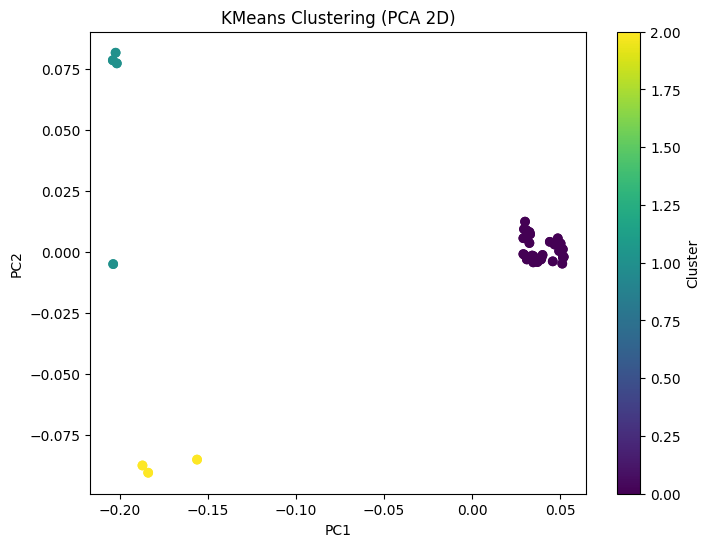

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_kmeans)

plt.title("KMeans Clustering (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Cluster")
plt.show()

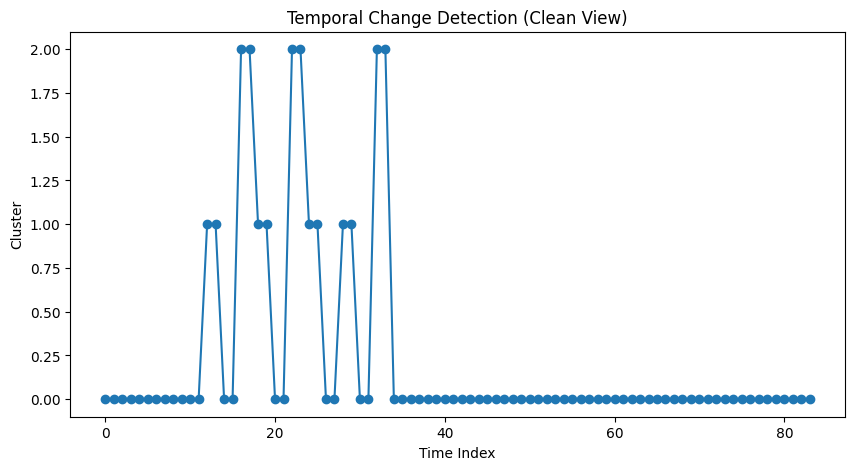

In [26]:
plt.figure(figsize=(10,5))
plt.plot(labels_kmeans, marker='o')

plt.xlabel("Time Index")
plt.ylabel("Cluster")
plt.title("Temporal Change Detection (Clean View)")

plt.show()

In [27]:
metadata_features = []

for item in filtered_items:
    
    # Encode orbit
    orbit = 1 if item.properties['sat:orbit_state'] == 'ascending' else 0
    
    # Encode direction
    direction = 1 if item.properties['sar:observation_direction'] == 'right' else 0
    
    # Incidence angle
    angle = item.properties['view:incidence_angle']
    
    metadata_features.append([orbit, direction, angle])

metadata_features = np.array(metadata_features)

print("Metadata shape:", metadata_features.shape)

Metadata shape: (84, 3)


In [28]:
features_combined = np.hstack((features, metadata_features))

print("Combined shape:", features_combined.shape)

Combined shape: (84, 131)


In [29]:
kmeans = KMeans(n_clusters=3, random_state=0)
labels_combined = kmeans.fit_predict(features_combined)

score_combined = silhouette_score(features_combined, labels_combined)

print("Combined Score:", score_combined)

Combined Score: 0.8800361086557502


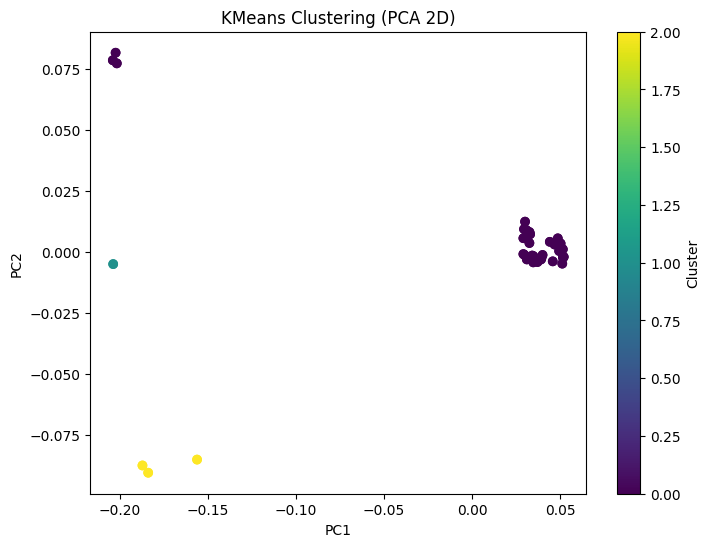

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_combined)

plt.title("KMeans Clustering (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Cluster")
plt.show()

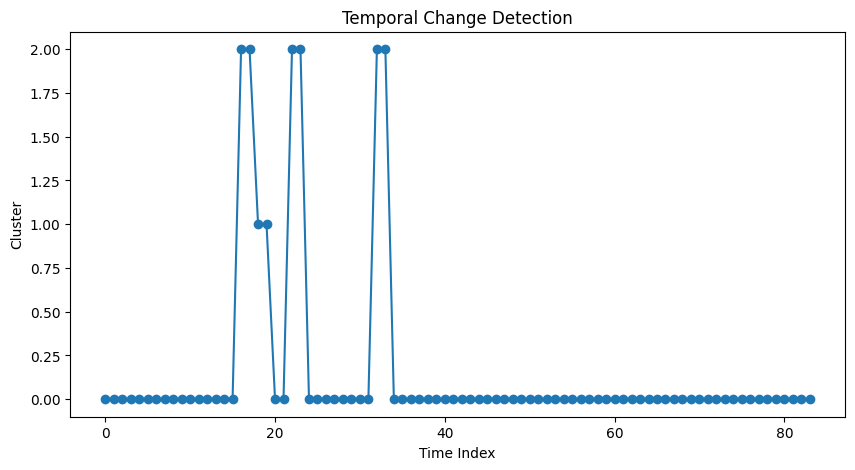

In [34]:
plt.figure(figsize=(10,5))
plt.plot(labels_combined, marker='o')

plt.xlabel("Time Index")
plt.ylabel("Cluster")
plt.title("Temporal Change Detection")

plt.show()